In [95]:
# ====================================================================
# Three-Class Classification: Drinking, Eating, Not_Drinking
# ====================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tcn import TCN
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
rng = np.random.default_rng(325)
tf.keras.utils.set_random_seed(325)
tf.debugging.enable_check_numerics()

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [96]:
# How many eating sequences do I have *before* concatenation?
eating_raw = pd.read_excel("eating_sequence_processed.xlsx")

print("Unique sip_id in raw file :", eating_raw['sip_id'].nunique())
print("Top 5 sip_id counts\n", eating_raw['sip_id'].value_counts().head())

Unique sip_id in raw file : 15
Top 5 sip_id counts
 sip_id
4    3784
2    3404
3    3320
5    3001
1    2820
Name: count, dtype: int64


In [97]:
# ====================================================================
# Load and combine drinking and eating data (sip-based approach)
# ====================================================================

# Load drinking data files
DRINKING_FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "previous_dv0_withstraw_sipCAdded.xlsx",
    "dv0_withoutstraw_sipCAdded.xlsx",
     
    "dv0_withstraw_sipCAdded.xlsx",
]

# Load and combine drinking data (same as before)
drinking_dfs = []
next_offset = 0

for fp in DRINKING_FILES:
    df = pd.read_excel(fp)
    
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp}: original IDs {old_min} … {old_max}")
    
    df["Participant_ID"] += next_offset
    next_offset = df["Participant_ID"].max() + 1
    
    drinking_dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")

drinking_combined = pd.concat(drinking_dfs, ignore_index=True)
print(f"\nDrinking data shape: {drinking_combined.shape}")

# Load eating data with sip_id
eating_data = pd.read_excel("eating_sequence_processed.xlsx")
print(f"Eating data shape: {eating_data.shape}")

# Shift eating Participant_IDs to avoid conflicts
eating_offset = drinking_combined['Participant_ID'].max() + 1
eating_data['Participant_ID'] += eating_offset
print(f"Eating Participant_IDs shifted to: {eating_data['Participant_ID'].min()} … {eating_data['Participant_ID'].max()}")

previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
previous_dv0_withstraw_sipCAdded.xlsx: original IDs 9 … 59
   shifted to 72 … 122
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 124 … 137
dv0_withstraw_sipCAdded.xlsx: original IDs 1 … 5
   shifted to 139 … 143

Drinking data shape: (134974, 82)
Eating data shape: (25872, 68)
Eating Participant_IDs shifted to: 145 … 170


In [98]:
# ====================================================================
# Prepare combined data for three-class classification (sip-based)
# ====================================================================

# Select relevant columns from drinking data
drinking_features = drinking_combined.iloc[:, 2:66]  # Skip Participant_ID and Label columns
drinking_features['Participant_ID'] = drinking_combined['Participant_ID']
drinking_features['Label'] = drinking_combined['Label']
drinking_features['sip_id'] = drinking_combined['sip_id']
drinking_features['dV'] = drinking_combined['dV']

# Remove time column from eating data if it exists
if 'Time' in eating_data.columns:
    eating_data_no_time = eating_data.drop('Time', axis=1)
else:
    eating_data_no_time = eating_data

# Ensure column alignment
print("Drinking data columns:", drinking_features.columns.tolist())
print("Eating data columns:", eating_data_no_time.columns.tolist())

# Combine drinking and eating data
all_data = pd.concat([drinking_features, eating_data_no_time], ignore_index=True)
print(f"\nCombined data shape: {all_data.shape}")

# Fix label mapping to handle both numeric and string labels
def map_label_to_three_class(label):
    if pd.isna(label):
        return np.nan
    
    # Handle string labels
    if isinstance(label, str):
        if label == 'Not_Drinking':
            return 0
        elif label == 'Drinking':
            return 1
        elif label == 'Eating':
            return 2
        else:
            return np.nan
    
    # Handle numeric labels
    elif isinstance(label, (int, float)):
        if label == 0:
            return 0  # Not_Drinking
        elif label == 1:
            return 1  # Drinking
        else:
            return np.nan
    
    return np.nan

# Apply the mapping
all_data['Three_Class_Label'] = all_data['Label'].apply(map_label_to_three_class)

print("\nThree-class label distribution:")
print(all_data['Three_Class_Label'].value_counts().sort_index())
print(f"NaN values: {all_data['Three_Class_Label'].isna().sum()}")

# Remove rows with NaN labels
all_data = all_data.dropna(subset=['Three_Class_Label'])
print(f"Data shape after removing NaN: {all_data.shape}")

Drinking data columns: ['Zone_0', 'Zone_1', 'Zone_2', 'Zone_3', 'Zone_4', 'Zone_5', 'Zone_6', 'Zone_7', 'Zone_8', 'Zone_9', 'Zone_10', 'Zone_11', 'Zone_12', 'Zone_13', 'Zone_14', 'Zone_15', 'Zone_16', 'Zone_17', 'Zone_18', 'Zone_19', 'Zone_20', 'Zone_21', 'Zone_22', 'Zone_23', 'Zone_24', 'Zone_25', 'Zone_26', 'Zone_27', 'Zone_28', 'Zone_29', 'Zone_30', 'Zone_31', 'Zone_32', 'Zone_33', 'Zone_34', 'Zone_35', 'Zone_36', 'Zone_37', 'Zone_38', 'Zone_39', 'Zone_40', 'Zone_41', 'Zone_42', 'Zone_43', 'Zone_44', 'Zone_45', 'Zone_46', 'Zone_47', 'Zone_48', 'Zone_49', 'Zone_50', 'Zone_51', 'Zone_52', 'Zone_53', 'Zone_54', 'Zone_55', 'Zone_56', 'Zone_57', 'Zone_58', 'Zone_59', 'Zone_60', 'Zone_61', 'Zone_62', 'Zone_63', 'Participant_ID', 'Label', 'sip_id', 'dV']
Eating data columns: ['Zone_0', 'Zone_1', 'Zone_2', 'Zone_3', 'Zone_4', 'Zone_5', 'Zone_6', 'Zone_7', 'Zone_8', 'Zone_9', 'Zone_10', 'Zone_11', 'Zone_12', 'Zone_13', 'Zone_14', 'Zone_15', 'Zone_16', 'Zone_17', 'Zone_18', 'Zone_19', 'Zone_2

In [99]:
# ====================================================================
# Fix the label mapping to handle both numeric and string labels CORRECTLY
# ====================================================================

def map_label_to_three_class_corrected(row):
    """
    Correctly map labels to three-class system.
    For drinking data: 0=Not_Drinking, 1=Drinking
    For eating data: Not_Drinking=Not_Drinking, Eating=Eating
    """
    label = row['Label']
    participant_id = row['Participant_ID']
    
    # Check if this is drinking data (lower participant IDs)
    is_drinking_data = participant_id < 100
    
    if pd.isna(label):
        return np.nan
    
    # Handle string labels (eating data)
    if isinstance(label, str):
        if label == 'Not_Drinking':
            return 0
        elif label == 'Drinking':
            return 1
        elif label == 'Eating':
            return 2
        else:
            return np.nan
    
    # Handle numeric labels (drinking data)
    elif isinstance(label, (int, float)):
        if is_drinking_data:
            # For drinking data: 0=Not_Drinking, 1=Drinking
            if label == 0:
                return 0  # Not_Drinking
            elif label == 1:
                return 1  # Drinking
            else:
                return np.nan
        else:
            # For eating data with numeric labels (shouldn't happen but just in case)
            return np.nan
    
    return np.nan

# Apply the corrected mapping
all_data['Three_Class_Label'] = all_data.apply(map_label_to_three_class_corrected, axis=1)

print("\nThree-class label distribution after CORRECTED mapping:")
print(all_data['Three_Class_Label'].value_counts().sort_index())
print(f"NaN values remaining: {all_data['Three_Class_Label'].isna().sum()}")

# Check the mapping worked correctly
print("\nSample of corrected mapped labels:")
sample_data = all_data[['Participant_ID', 'Label', 'Three_Class_Label']].head(20)
display(sample_data)


Three-class label distribution after CORRECTED mapping:
Three_Class_Label
0.0    106987
1.0      6572
2.0      1610
Name: count, dtype: int64
NaN values remaining: 45677

Sample of corrected mapped labels:


,Participant_ID,Label,Three_Class_Label
0,6,0,0.0
1,6,0,0.0
2,6,0,0.0
3,6,0,0.0
4,6,0,0.0
5,6,0,0.0
6,6,0,0.0
7,6,0,0.0
8,6,0,0.0
9,6,0,0.0


In [100]:
# ====================================================================
# Filter drinking data for zero dV (but keep all eating data)
# ====================================================================

def filter_drinking_data(df):
    """
    Filter drinking data to remove zero dV sips, but keep all eating data.
    """
    filtered_data = []
    
    for _, group in df.groupby(['Participant_ID', 'sip_id', 'Label']):
        label = group['Label'].iloc[0]
        
        # For drinking data, check dV
        if label == 'Drinking' and 'dV' in group.columns:
            dV = float(group['dV'].iloc[0])
            if dV == 0.0:
                continue  # Skip zero dV drinking sips
        
        # Keep all eating and Not_Drinking data
        filtered_data.append(group)
    
    return pd.concat(filtered_data, ignore_index=True)

# Apply filtering to drinking data only
print("Filtering drinking data for zero dV...")
all_data_filtered = filter_drinking_data(all_data)

print(f"Original data shape: {all_data.shape}")
print(f"Filtered data shape: {all_data_filtered.shape}")
print(f"Rows removed: {len(all_data) - len(all_data_filtered)}")

# Use filtered data for sequence creation
all_data = all_data_filtered

Filtering drinking data for zero dV...
Original data shape: (160846, 69)
Filtered data shape: (160846, 69)
Rows removed: 0


In [101]:
# ====================================================================
# Create sip-based sequences (STANDARD APPROACH like combined_classification.ipynb)
# ====================================================================

# def create_sip_sequences_simple(df):
#     """
#     Create sequences using simple approach like the original combined_classification.ipynb
#     """
#     sequences = []
#     labels = []
#     participant_ids = []
#     sip_ids = []
    
#     # Group by Participant_ID, sip_id, and Label (simple approach)
#     seq_keys = ["Participant_ID", "sip_id", "Label"]
    
#     for _, group in df.groupby(seq_keys, sort=False):
#         # Get the label for this sip
#         label = group["Three_Class_Label"].iloc[0]
        
#         # Skip if label is NaN
#         if pd.isna(label):
#             continue
            
#         # For drinking data, check dV (skip zero dV drinking sips)
#         if group["Label"].iloc[0] == 1 and "dV" in group.columns:
#             dV = float(group["dV"].iloc[0])
#             if dV == 0.0:
#                 continue  # Skip zero dV drinking sips
        
#         # Get the feature data for this sip
#         feature_cols = [col for col in group.columns if col.startswith('Zone_')]
#         sip_data = group[feature_cols].to_numpy(np.float32)  # (T, 64)
        
#         # Include all sips (no minimum length filter)
#         sequences.append(sip_data)
#         labels.append(int(label))
#         participant_ids.append(group["Participant_ID"].iloc[0])
#         sip_ids.append(group["sip_id"].iloc[0])
    
#     return sequences, np.array(labels, dtype=np.int32), np.array(participant_ids), np.array(sip_ids)
def create_sip_sequences_simple(df):
    sequences = []
    labels = []
    participant_ids = []
    sip_ids = []
    is_original = []  # NEW

    seq_keys = ["Participant_ID", "sip_id", "Label"]
    for _, group in df.groupby(seq_keys, sort=False):
        label = group["Three_Class_Label"].iloc[0]
        if pd.isna(label):
            continue
        if group["Label"].iloc[0] == 1 and "dV" in group.columns:
            dV = float(group["dV"].iloc[0])
            if dV == 0.0:
                continue
        feature_cols = [col for col in group.columns if col.startswith('Zone_')]
        sip_data = group[feature_cols].to_numpy(np.float32)
        sequences.append(sip_data)
        labels.append(int(label))
        participant_ids.append(group["Participant_ID"].iloc[0])
        sip_ids.append(group["sip_id"].iloc[0])
        is_original.append(True)  # All sequences here are original

    return sequences, np.array(labels, dtype=np.int32), np.array(participant_ids), np.array(sip_ids), np.array(is_original, dtype=bool)
# Create sequences using standard approach
print("Creating sip-based sequences using standard approach...")
# X_sequences, y_sequences, participant_ids, sip_ids = create_sip_sequences_simple(all_data)
X_sequences, y_sequences, participant_ids, sip_ids, is_original = create_sip_sequences_simple(all_data)
print(f"Total sequences: {len(X_sequences)}")
print(f"Label distribution: {np.bincount(y_sequences)}")
print(f"Unique participants: {len(np.unique(participant_ids))}")

# Show class distribution
print("\nClass distribution:")
class_names = ["Not_Drinking", "Drinking", "Eating"]
for i, name in enumerate(class_names):
    count = (y_sequences == i).sum()
    print(f"  {name}: {count}")

# Check by data type
print("\nSequences by data type:")
drinking_sequences = sum(1 for p in participant_ids if p < 100)  # Drinking data
eating_sequences = sum(1 for p in participant_ids if p >= 100)   # Eating data

print(f"  Drinking sequences: {drinking_sequences}")
print(f"  Eating sequences: {eating_sequences}")

# Show sample sequences
print(f"\nSample sequences:")
for i in range(min(3, len(X_sequences))):
    print(f"Sequence {i}: shape {X_sequences[i].shape}, label {y_sequences[i]}, participant {participant_ids[i]}, sip_id {sip_ids[i]}")

# Check by participant
print(f"\nSequences by participant (first 10):")
participant_counts = {}
for participant_id in participant_ids:
    if participant_id not in participant_counts:
        participant_counts[participant_id] = 0
    participant_counts[participant_id] += 1

for i, (participant_id, count) in enumerate(sorted(participant_counts.items())):
    if i < 10:  # Show first 10
        print(f"  Participant {participant_id}: {count} sequences")
    else:
        break

Creating sip-based sequences using standard approach...
Total sequences: 1204
Label distribution: [639 375 190]
Unique participants: 72

Class distribution:
  Not_Drinking: 639
  Drinking: 375
  Eating: 190

Sequences by data type:
  Drinking sequences: 798
  Eating sequences: 406

Sample sequences:
Sequence 0: shape (241, 64), label 0, participant 6, sip_id 0
Sequence 1: shape (83, 64), label 0, participant 6, sip_id 1
Sequence 2: shape (26, 64), label 1, participant 6, sip_id 1

Sequences by participant (first 10):
  Participant 6: 13 sequences
  Participant 7: 15 sequences
  Participant 8: 13 sequences
  Participant 10: 17 sequences
  Participant 11: 17 sequences
  Participant 13: 25 sequences
  Participant 14: 21 sequences
  Participant 16: 29 sequences
  Participant 17: 13 sequences
  Participant 19: 9 sequences


In [102]:
# import numpy as np
# from sklearn.model_selection import train_test_split

# X_sequences = np.array(X_sequences, dtype=object)
# y_sequences = np.array(y_sequences)
# is_original = np.array(is_original)

# train_idx, test_idx = [], []

# for c in [0, 1, 2]:  # for each class
#     idx = np.where((y_sequences == c) & (is_original == True))[0]
#     idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, shuffle=True)
#     train_idx.extend(idx_train)
#     test_idx.extend(idx_test)

# train_idx = np.array(train_idx)
# test_idx = np.array(test_idx)

# X_trainval, y_trainval, is_original_trainval = X_sequences[train_idx], y_sequences[train_idx], is_original[train_idx]
# X_test, y_test = X_sequences[test_idx], y_sequences[test_idx]

In [103]:
# from collections import Counter
# counts = Counter(y_trainval)
# max_count = max(counts.values())
# print("Train/val class counts before augmentation:", counts)

In [104]:


def add_gaussian_noise(sip):
    sigma_ratio = 0.1  # or your chosen value
    std_dev = sigma_ratio * 4000
    noise = np.random.normal(0, std_dev, sip.shape)
    noisy_sip = sip + noise
    return np.clip(noisy_sip, a_min=0.0, a_max=None)

def flip_horizontal(sip):
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

def rotate_frame(frame, angle):
    from scipy.ndimage import rotate
    frame_8x8 = frame.reshape(8, 8)
    rotated = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')
    return rotated.flatten()

def rotate_sip(sip, angle):
    return np.array([rotate_frame(frame, angle) for frame in sip], dtype=np.float32)

In [105]:
# aug_X, aug_y = list(X_trainval), list(y_trainval)
# aug_is_original = [True] * len(X_trainval)  # All originals so far
# for c in [0, 1, 2]:
#     idx = np.where(y_trainval == c)[0]
#     needed = max_count - len(idx)
#     if needed > 0:
#         for i in range(needed):
#             orig_idx = np.random.choice(idx)
#             x_aug = X_trainval[orig_idx]
#             aug_type = np.random.choice(['flip', 'noise', 'rotate'])
#             if aug_type == 'flip':
#                 x_aug = flip_horizontal(x_aug)
#             elif aug_type == 'noise':
#                 x_aug = add_gaussian_noise(x_aug)
#             elif aug_type == 'rotate':
#                 angle = np.random.choice([5, -5, 10, -10, 20, -20,30, -30, 45, -45])
#                 x_aug = rotate_sip(x_aug, angle)
#             aug_X.append(x_aug)
#             aug_y.append(c)
#             aug_is_original.append(False)  # <--- Track as augmented

In [106]:
# from sklearn.utils import shuffle
# X_trainval_bal, y_trainval_bal = shuffle(np.array(aug_X, dtype=object), np.array(aug_y), random_state=42)

In [107]:
# # ====================================================================
# # Split data (EXACTLY like combined_classification.ipynb)
# # ====================================================================
# # Use the same split as combined_classification.ipynb
# idx = rng.permutation(len(X_sequences))
# split1 = int(.64 * len(X_sequences))          # 64 % train
# split2 = int(.80 * len(X_sequences))          # next 16 % val

# # Convert to numpy arrays for indexing
# X_sequences_array = np.array(X_sequences, dtype=object)
# y_sequences_array = np.array(y_sequences)

# X_train, y_train = X_sequences_array[idx[:split1]], y_sequences_array[idx[:split1]]
# X_val,   y_val   = X_sequences_array[idx[split1:split2]], y_sequences_array[idx[split1:split2]]
# X_test,  y_test  = X_sequences_array[idx[split2:]], y_sequences_array[idx[split2:]]

# # Convert back to lists for the rest of the pipeline
# X_train = list(X_train)
# X_val = list(X_val)
# X_test = list(X_test)

# print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")

# # Check class distribution in splits
# print("\nClass distribution in splits:")
# print(f"Train: {np.bincount(y_train)}")
# print(f"Validation: {np.bincount(y_val)}")
# print(f"Test: {np.bincount(y_test)}")
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter

# Set your desired test percentages for each class
test_percentages = {0: 0.2, 1: 0.4, 2: 0.8}  # 0=not drinking, 1=drinking, 2=eating

X_sequences_array = np.array(X_sequences, dtype=object)
y_sequences_array = np.array(y_sequences)
is_original_array = np.array(is_original)

train_idx, test_idx = [], []

# 1. Split original data into train and test per class
for c in [0, 1, 2]:
    idx = np.where((y_sequences_array == c) & (is_original_array == True))[0]
    test_size = test_percentages.get(c, 0.2)
    if len(idx) < 5:
        test_idx.extend(idx)
        continue
    idx_train, idx_test = train_test_split(idx, test_size=test_size, random_state=42, shuffle=True)
    train_idx.extend(idx_train)
    test_idx.extend(idx_test)

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

# 2. Test set: only original samples (user-controlled percentage per class)
X_test, y_test = X_sequences_array[test_idx], y_sequences_array[test_idx]

# 3. Train/val: all original (not in test) + all augmented
augmented_idx = np.where(is_original_array == False)[0]
trainval_idx = np.concatenate([train_idx, augmented_idx])

X_trainval, y_trainval = X_sequences_array[trainval_idx], y_sequences_array[trainval_idx]

print("Before augmentation:", len(X_trainval), Counter(y_trainval))

# Set how many noise augmentations you want per class
noise_augmentations = {0: 0, 1: 1, 2: 7}  # Example: more for eating

# Set rotation angles (unique, no repeats)
rotation_angles = [5, -5, 10, -10, 20, -20, 30, -30, 45, -45]

aug_X, aug_y = list(X_trainval), list(y_trainval)

for c in [0, 1, 2]:
    idx = np.where(y_trainval == c)[0]
    for orig_idx in idx:
        x_orig = X_trainval[orig_idx]
        # 1. Flip (once)
        x_flip = flip_horizontal(x_orig)
        aug_X.append(x_flip)
        aug_y.append(c)
        # 2. Rotations (once per angle)
        for angle in rotation_angles:
            x_rot = rotate_sip(x_orig, angle)
            aug_X.append(x_rot)
            aug_y.append(c)
        # 3. Noise (as many times as you want for this class)
        for _ in range(noise_augmentations[c]):
            x_noise = add_gaussian_noise(x_orig)
            aug_X.append(x_noise)
            aug_y.append(c)

print("After augmentation:", len(aug_X), Counter(aug_y))

# 5. Final train/val split from the balanced, augmented set
X_trainval_bal = np.array(aug_X, dtype=object)
y_trainval_bal = np.array(aug_y)

rng = np.random.default_rng(42)
idx_tv = rng.permutation(len(X_trainval_bal))
split_tv = int(.8 * len(X_trainval_bal))
X_train, y_train = X_trainval_bal[idx_tv[:split_tv]], y_trainval_bal[idx_tv[:split_tv]]
X_val, y_val = X_trainval_bal[idx_tv[split_tv:]], y_trainval_bal[idx_tv[split_tv:]]

print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")

# 6. Check class distribution in splits
def print_class_dist(y, name):
    bincount = np.bincount(y)
    print(f"{name}: {bincount} (total: {len(y)})")
print('\nClass distribution in splits:')
print_class_dist(y_train, "Train")
print_class_dist(y_val, "Validation")
print_class_dist(y_test, "Test")

Before augmentation: 774 Counter({np.int32(0): 511, np.int32(1): 225, np.int32(2): 38})
After augmentation: 9779 Counter({np.int32(0): 6132, np.int32(1): 2925, np.int32(2): 722})
Train 7823 Val 1956  Test 430

Class distribution in splits:
Train: [4929 2315  579] (total: 7823)
Validation: [1203  610  143] (total: 1956)
Test: [128 150 152] (total: 430)


In [108]:
# ====================================================================
# Normalize data (EXACTLY like combined_classification.ipynb)
# ====================================================================

# Column-wise z-score normalisation (fit on training only)
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train_norm = [norm(s) for s in X_train]
X_val_norm   = [norm(s) for s in X_val]
X_test_norm  = [norm(s) for s in X_test]

# No label scaling needed for classification
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test

print("Data shapes after normalization:")
print(f"X_train: {len(X_train_norm)} sequences")
print(f"X_val: {len(X_val_norm)} sequences")
print(f"X_test: {len(X_test_norm)} sequences")

Data shapes after normalization:
X_train: 7823 sequences
X_val: 1956 sequences
X_test: 430 sequences


In [109]:
# ====================================================================
# Create tf.data pipelines (EXACTLY like combined_classification.ipynb)
# ====================================================================

BATCH = 1  # Use batch size 1 for variable length sequences

def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

print("Data pipelines created successfully!")

Data pipelines created successfully!


In [110]:
# ====================================================================
# Create TCN model for three-class classification (variable length)
# ====================================================================

num_classes = 3  # Not_Drinking, Drinking, Eating

# Input shape: (None, 64) - variable length sequences with 64 features
inp = tf.keras.Input(shape=(None, 64))
x = TCN(
    nb_filters=128,
    kernel_size=2,
    dilations=[1, 2, 4, 8, 16, 32],
    dropout_rate=0.1,
    return_sequences=False
)(inp)
out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inp, out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_5 (TCN)                     │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,075 (1.48 MB)

 Trainable params: 387,075 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [111]:
# ====================================================================
# Train the model (variable length sequences)
# ====================================================================

BATCH_SIZE = 1  # Use batch size 1 for variable length sequences

# Create data generators for variable length sequences
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),  # Variable length, 64 features
    tf.TensorSpec((), tf.int32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: generator(xs, ys),
        output_signature=output_sig
    )
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    return ds.repeat().batch(BATCH_SIZE)  # Ragged batches

train_ds = make_ds(X_train_norm, y_train, shuffle=True)
val_ds = make_ds(X_val_norm, y_val, shuffle=False)
test_ds = make_ds(X_test_norm, y_test, shuffle=False)

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

# Train
history = model.fit(
    train_ds,
    epochs=50,
    steps_per_epoch=len(X_train_norm),
    validation_data=val_ds,
    validation_steps=len(X_val_norm),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
7823/7823 ━━━━━━━━━━━━━━━━━━━━ 115s 14ms/step - accuracy: 0.9255 - loss: 0.6833 - val_accuracy: 0.9525 - val_loss: 0.1413
Epoch 2/50
7823/7823 ━━━━━━━━━━━━━━━━━━━━ 106s 14ms/step - accuracy: 0.9581 - loss: 0.1573 - val_accuracy: 0.9719 - val_loss: 0.0918
Epoch 3/50
7823/7823 ━━━━━━━━━━━━━━━━━━━━ 118s 15ms/step - accuracy: 0.9650 - loss: 0.1385 - val_accuracy: 0.9657 - val_loss: 0.1980
Epoch 4/50
7823/7823 ━━━━━━━━━━━━━━━━━━━━ 125s 16ms/step - accuracy: 0.9632 - loss: 0.1481 - val_accuracy: 0.9749 - val_loss: 0.2203
Epoch 5/50
7823/7823 ━━━━━━━━━━━━━━━━━━━━ 115s 15ms/step - accuracy: 0.9750 - loss: 0.1208 - val_accuracy: 0.9801 - val_loss: 0.0712
Epoch 6/50
7823/7823 ━━━━━━━━━━━━━━━━━━━━ 106s 14ms/step - accuracy: 0.9738 - loss: 0.1183 - val_accuracy: 0.9811 - val_loss: 0.0687
Epoch 7/50
7823/7823 ━━━━━━━━━━━━━━━━━━━━ 110s 14ms/step - accuracy: 0.9776 - loss: 0.1349 - val_accuracy: 0.9780 - val_loss: 0.1200
Epoch 8/50
7823/7823 ━━━━━━━━━━━━━━━━━━━━ 107s 14ms/step - accuracy: 

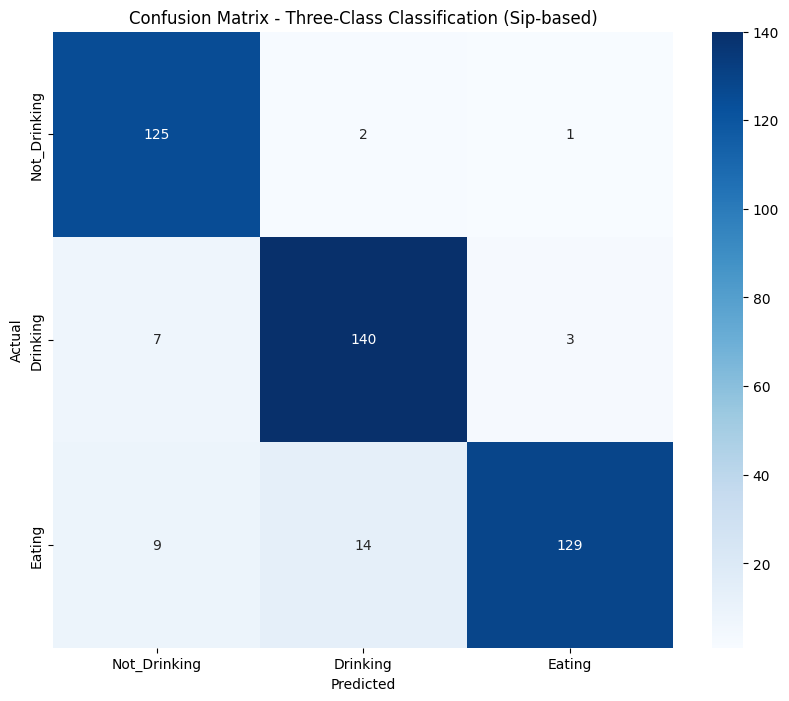


Classification Report:
              precision    recall  f1-score   support

Not_Drinking       0.89      0.98      0.93       128
    Drinking       0.90      0.93      0.92       150
      Eating       0.97      0.85      0.91       152

    accuracy                           0.92       430
   macro avg       0.92      0.92      0.92       430
weighted avg       0.92      0.92      0.92       430


Overall Metrics:
Accuracy: 0.9163
Precision: 0.9198
Recall: 0.9163
F1-Score: 0.9158


In [112]:
# ====================================================================
# Evaluate model and create confusion matrix (variable length)
# ====================================================================

# Predictions for variable length sequences
y_pred_probs = []
for seq in X_test_norm:
    pred = model.predict(seq[None, ...], verbose=0)[0]
    y_pred_probs.append(pred)

y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
class_names = ["Not_Drinking", "Drinking", "Eating"]
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Three-Class Classification (Sip-based)')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Additional metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

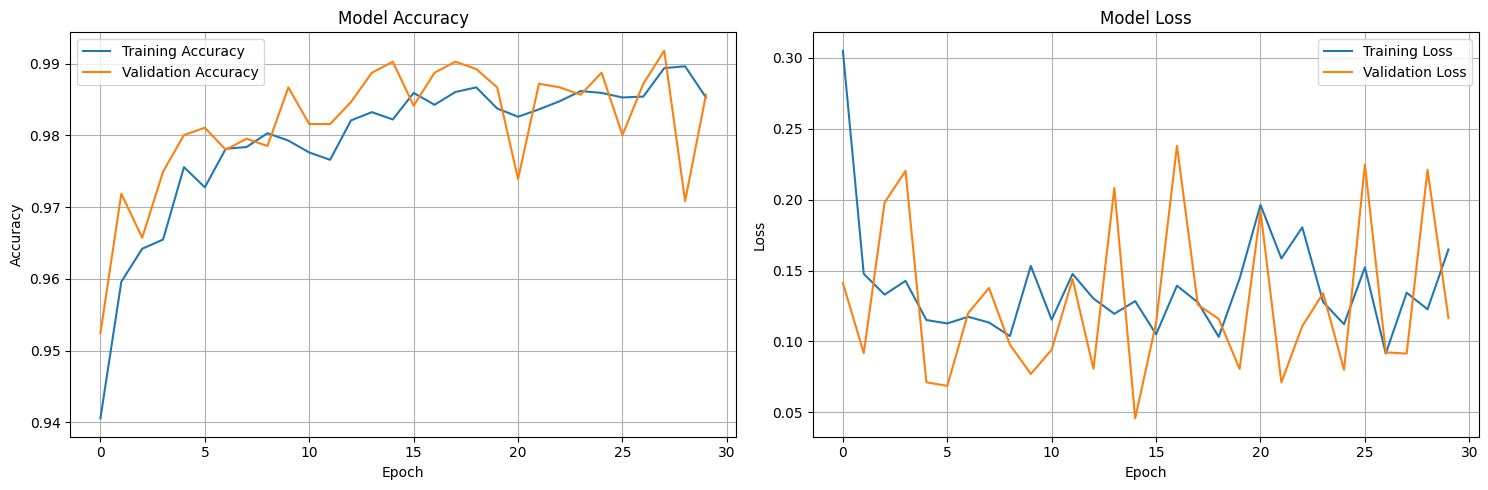

In [113]:
# ====================================================================
# Plot training history
# ====================================================================

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [114]:
# ====================================================================
# Save model and results
# ====================================================================

# Save the trained model using the newer Keras format
model.save('three_class_tcn_model.keras')
print("Model saved as 'three_class_tcn_model.keras'")

# Save predictions and results
results_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'True_Class': [class_names[i] for i in y_test],
    'Predicted_Class': [class_names[i] for i in y_pred]
})

results_df.to_excel('classification_results.xlsx', index=False)
print("Results saved as 'classification_results.xlsx'")

# Print final summary
print(f"\nFinal Model Performance:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")

Model saved as 'three_class_tcn_model.keras'
Results saved as 'classification_results.xlsx'

Final Model Performance:
Test Accuracy: 0.9163
Test Precision: 0.9198
Test Recall: 0.9163
Test F1-Score: 0.9158
